In [1]:
!pip -q install lifelines scikit-survival chronos-forecasting

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 90.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.6/80.6 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 19.5 MB/s eta 0:00:00


# VERİ

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import gamma as gammafn
from lifelines import NelsonAalenFitter
from lifelines.utils import concordance_index
from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from chronos import ChronosPipeline

SEED = 7
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

df = pd.read_csv("autism.csv")
df["tau"] = df["sure_dk"] + df["bekleme_dk"]
df["T"] = df.groupby("oturum")["tau"].cumsum() - df["tau"]
E = df[["oturum", "T", "tau", "delta"]]

tau = E["tau"].to_numpy(float)
delta = E["delta"].to_numpy(float)
T_prev = E["T"].to_numpy(float)

L = 16
H = 40
V = 40
P = 0.5

X = np.stack([tau[i - L:i] for i in range(L, len(tau))])
y = tau[L:]
d = delta[L:]
Tp = T_prev[L:]

n_tr = len(y) - H
X_tr, X_te = X[:n_tr], X[n_tr:]
y_tr, y_te = y[:n_tr], y[n_tr:]
d_tr, d_te = d[:n_tr], d[n_tr:]
Tp_te = Tp[n_tr:]
T_te = Tp_te + y_te
obs = d_te == 1

TAU_HAT = {}
T_HAT = {}

pd.DataFrame({"n_epizot": [len(E)], "n_oturum": [E["oturum"].nunique()], "L": [L],
              "n_train": [len(y_tr)], "n_test": [len(y_te)], "n_test_sansur": [int((~obs).sum())],
              "sansur_orani": [1.0 - delta.mean()], "tau_ort": [tau.mean()],
              "tau_std": [tau.std()]}).round(3)

,n_epizot,n_oturum,L,n_train,n_test,n_test_sansur,sansur_orani,tau_ort,tau_std
0,268,36,16,212,40,7,0.134,15.413,9.072


# MODEL

## Deterministik

In [3]:
naf = NelsonAalenFitter()
naf.fit(y_tr, event_observed=d_tr)

grid = naf.cumulative_hazard_.index.to_numpy()
Lam = naf.cumulative_hazard_.to_numpy().ravel()
S = np.exp(-Lam)
F = 1.0 - S

q = min(int(np.searchsorted(F, P)), len(grid) - 1)
tau_hat = np.full(H, float(grid[q]))

TAU_HAT["Deterministik"] = tau_hat
T_HAT["Deterministik"] = Tp_te + tau_hat

pd.Series({"tau_hat": float(grid[q]), "S": float(S[q]), "F": float(F[q])}).round(4)

,0
tau_hat,15.0820
S,0.4967
F,0.5033


## Stokastik

In [4]:
def log_psi(theta, x):
    w, a, b = theta[0], theta[1], theta[2]
    lx = np.log(x)
    lp = np.empty(len(x))
    lp[0] = np.log(x.mean())
    for t in range(1, len(x)):
        lp[t] = w + a * lx[t - 1] + b * lp[t - 1]
    return np.clip(lp, -10.0, 10.0)


def acd_nll(theta, x, e):
    k = float(np.exp(np.clip(theta[3], -5.0, 5.0)))
    lam = np.exp(log_psi(theta, x)) / gammafn(1.0 + 1.0 / k)
    z = x / lam
    v = e * (np.log(k) - np.log(lam) + (k - 1.0) * np.log(z)) - z ** k
    if not np.all(np.isfinite(v)):
        return 1e12
    return -float(np.sum(v))


tau_fit = tau[:L + n_tr]
delta_fit = delta[:L + n_tr]
theta0 = np.array([np.log(tau_fit.mean()) * 0.2, -0.3, 0.5, np.log(2.0)])
res = minimize(acd_nll, theta0, args=(tau_fit, delta_fit), method="Nelder-Mead",
               options={"maxiter": 50000, "maxfev": 50000, "xatol": 1e-9, "fatol": 1e-9})

k = float(np.exp(res.x[3]))
lam_all = np.exp(log_psi(res.x, tau)) / gammafn(1.0 + 1.0 / k)
tau_hat = lam_all[L + n_tr:] * np.log(1.0 / (1.0 - P)) ** (1.0 / k)

TAU_HAT["Stokastik"] = tau_hat
T_HAT["Stokastik"] = Tp_te + tau_hat

pd.Series({"omega": res.x[0], "alpha": res.x[1], "beta": res.x[2],
           "k": k, "nll": res.fun}).round(4)

,0
omega,3.0760
alpha,-0.3198
beta,0.1822
k,1.8710
nll,707.1406


## ShallowML

In [5]:
y_surv = Surv.from_arrays(event=d_tr.astype(bool), time=y_tr)

rsf = RandomSurvivalForest(n_estimators=500, min_samples_leaf=5,
                           random_state=SEED, n_jobs=-1)
rsf.fit(X_tr, y_surv)

S_hat = rsf.predict_survival_function(X_te, return_array=True)
F_hat = 1.0 - S_hat
grid = rsf.unique_times_

reach = F_hat >= P
idx = np.where(reach.any(axis=1), reach.argmax(axis=1), len(grid) - 1)
tau_hat = grid[idx]

TAU_HAT["ShallowML"] = tau_hat
T_HAT["ShallowML"] = Tp_te + tau_hat

pd.DataFrame({"tau_hat": tau_hat[:5], "tau": y_te[:5], "delta": d_te[:5]}).round(3)

,tau_hat,tau,delta
0,11.996,11.969,1.0
1,17.443,23.512,0.0
2,9.634,13.878,1.0
3,17.656,34.416,1.0
4,12.359,31.591,1.0


## DeepML

In [6]:
def weibull_nll(alpha, beta, t, e):
    z = t / alpha
    ll = e * (torch.log(beta) - torch.log(alpha) + (beta - 1.0) * torch.log(z)) - z ** beta
    return -ll.mean()


def fit_early(model, in_tr, in_va, t_tr, e_tr, t_va, e_va, lr, wd, epochs):
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    best = float("inf")
    state = None
    for epoch in range(epochs):
        model.train()
        opt.zero_grad()
        alpha, beta = model(*in_tr)
        loss = weibull_nll(alpha, beta, t_tr, e_tr)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        model.eval()
        with torch.no_grad():
            av, bv = model(*in_va)
            v = float(weibull_nll(av, bv, t_va, e_va))
        if v < best:
            best = v
            state = {kk: vv.clone() for kk, vv in model.state_dict().items()}
    model.load_state_dict(state)
    model.eval()
    return best


class WeibullRNN(nn.Module):
    def __init__(self, hidden=16, p_drop=0.2):
        super().__init__()
        self.rnn = nn.LSTM(1, hidden, batch_first=True)
        self.drop = nn.Dropout(p_drop)
        self.head = nn.Linear(hidden, 2)

    def forward(self, x):
        h, _ = self.rnn(x)
        o = self.head(self.drop(h[:, -1, :]))
        return nn.functional.softplus(o[:, 0]) + 1e-2, nn.functional.softplus(o[:, 1]) + 0.5


mu_x = float(np.log(X_tr).mean())
sd_x = float(np.log(X_tr).std())
s_y = float(y_tr.mean())

Z_tr = torch.tensor((np.log(X_tr) - mu_x) / sd_x, dtype=torch.float32).unsqueeze(-1).to(DEVICE)
Z_te = torch.tensor((np.log(X_te) - mu_x) / sd_x, dtype=torch.float32).unsqueeze(-1).to(DEVICE)
t_all = torch.tensor(y_tr / s_y, dtype=torch.float32).to(DEVICE)
e_all = torch.tensor(d_tr, dtype=torch.float32).to(DEVICE)

torch.manual_seed(SEED)
deep = WeibullRNN().to(DEVICE)
v_deep = fit_early(deep, (Z_tr[:-V],), (Z_tr[-V:],), t_all[:-V], e_all[:-V],
                   t_all[-V:], e_all[-V:], 0.01, 0.01, 1500)

with torch.no_grad():
    alpha, beta = deep(Z_te)

tau_hat = (alpha * np.log(1.0 / (1.0 - P)) ** (1.0 / beta)).cpu().numpy() * s_y

TAU_HAT["DeepML"] = tau_hat
T_HAT["DeepML"] = Tp_te + tau_hat

pd.Series({"val_nll": v_deep, "alpha_ort": float(alpha.mean()) * s_y,
           "beta_ort": float(beta.mean())}).round(4)

,0
val_nll,1.0370
alpha_ort,17.4136
beta_ort,1.5579


## Foundation

In [7]:
pipeline = ChronosPipeline.from_pretrained("amazon/chronos-t5-small",
                                           device_map=DEVICE,
                                           torch_dtype=torch.float32)

ctx = torch.tensor(X_te, dtype=torch.float32)
samples = pipeline.predict(ctx, prediction_length=1, num_samples=200)
F_ctx = samples[:, :, 0]
tau_hat = torch.quantile(F_ctx, P, dim=1).numpy()

TAU_HAT["Foundation"] = tau_hat
T_HAT["Foundation"] = Tp_te + tau_hat

pd.DataFrame({"tau_hat": tau_hat[:5], "tau": y_te[:5], "delta": d_te[:5]}).round(3)

config.json:   0%|          | 0.00/1.11k [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B /  185MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

,tau_hat,tau,delta
0,13.955,11.969,1.0
1,12.547,23.512,0.0
2,13.005,13.878,1.0
3,13.914,34.416,1.0
4,14.398,31.591,1.0


## Headed

In [8]:
def encode(x, batch=32):
    zs, ss = [], []
    for i in range(0, len(x), batch):
        emb, state = pipeline.embed(torch.tensor(x[i:i + batch], dtype=torch.float32))
        zs.append(emb.float().mean(dim=1).cpu())
        ss.append(state.reshape(-1).float().cpu())
    return torch.cat(zs), torch.cat(ss)


class WeibullHead(nn.Module):
    def __init__(self, dim, p_drop=0.2):
        super().__init__()
        self.drop = nn.Dropout(p_drop)
        self.net = nn.Linear(dim, 2)

    def forward(self, z, scale):
        o = self.net(self.drop(z))
        alpha = (nn.functional.softplus(o[:, 0]) + 1e-2) * scale
        beta = nn.functional.softplus(o[:, 1]) + 0.5
        return alpha, beta


z_tr, s_tr = encode(X_tr)
z_te, s_te = encode(X_te)
z_tr, s_tr = z_tr.to(DEVICE), s_tr.to(DEVICE)
z_te, s_te = z_te.to(DEVICE), s_te.to(DEVICE)
t_raw = torch.tensor(y_tr, dtype=torch.float32).to(DEVICE)
e_raw = torch.tensor(d_tr, dtype=torch.float32).to(DEVICE)

torch.manual_seed(SEED)
head = WeibullHead(z_tr.shape[1]).to(DEVICE)
v_head = fit_early(head, (z_tr[:-V], s_tr[:-V]), (z_tr[-V:], s_tr[-V:]),
                   t_raw[:-V], e_raw[:-V], t_raw[-V:], e_raw[-V:], 0.01, 0.01, 1500)

with torch.no_grad():
    alpha, beta = head(z_te, s_te)

tau_hat = (alpha * np.log(1.0 / (1.0 - P)) ** (1.0 / beta)).cpu().numpy()

TAU_HAT["Headed"] = tau_hat
T_HAT["Headed"] = Tp_te + tau_hat

pd.Series({"z_dim": z_tr.shape[1], "val_nll": v_head,
           "alpha_ort": float(alpha.mean()), "beta_ort": float(beta.mean())}).round(4)

,0
z_dim,512.0000
val_nll,3.2587
alpha_ort,23.5693
beta_ort,1.8307


# DEĞERLENDİRME

In [9]:
order = ["Deterministik", "Stokastik", "ShallowML", "DeepML", "Foundation", "Headed"]

rows = []
for m in order:
    p = np.asarray(TAU_HAT[m], dtype=float)
    h = np.asarray(T_HAT[m], dtype=float)
    rows.append({
        "Model": m,
        "MAE_tau": np.mean(np.abs(y_te[obs] - p[obs])),
        "RMSE_tau": np.sqrt(np.mean((y_te[obs] - p[obs]) ** 2)),
        "MAPE_tau": np.mean(np.abs((y_te[obs] - p[obs]) / y_te[obs])) * 100.0,
        "MAE_T": np.mean(np.abs(T_te[obs] - h[obs])),
        "C_index": concordance_index(y_te, p, d_te),
    })

report = pd.DataFrame(rows).set_index("Model").round(4)
report

,MAE_tau,RMSE_tau,MAPE_tau,MAE_T,C_index
Model,,,,,
Deterministik,9.2450,11.5950,54.3779,9.2450,0.5000
Stokastik,8.2292,11.3064,42.5010,8.2292,0.6545
ShallowML,7.4394,9.9809,45.1029,7.4394,0.6553
DeepML,8.8129,11.7684,46.4390,8.8129,0.6497
Foundation,11.1830,14.9098,54.1185,11.1830,0.3869
Headed,10.0501,11.6353,74.8715,10.0501,0.4029


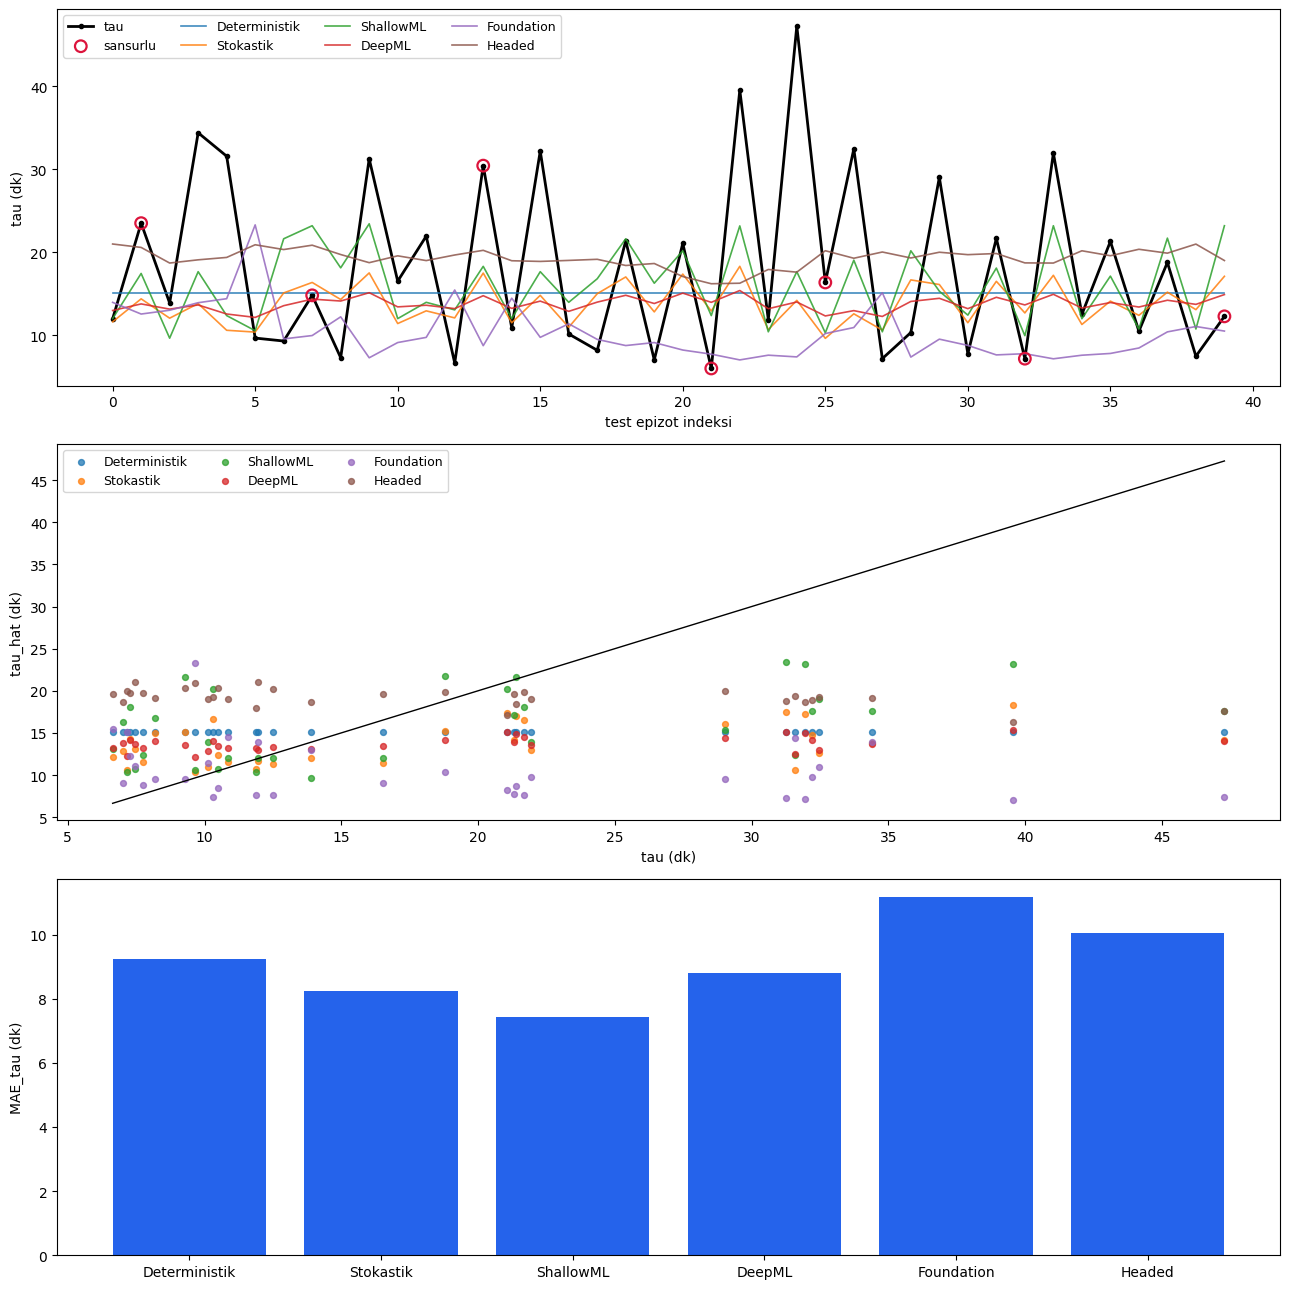

In [10]:
fig, ax = plt.subplots(3, 1, figsize=(13, 13))

ax[0].plot(y_te, color="black", linewidth=2.0, marker="o", markersize=3, label="tau")
ax[0].scatter(np.where(~obs)[0], y_te[~obs], s=70, facecolors="none",
              edgecolors="crimson", linewidths=1.6, zorder=5, label="sansurlu")
for m in order:
    ax[0].plot(np.asarray(TAU_HAT[m], dtype=float), linewidth=1.2, alpha=0.85, label=m)
ax[0].set_xlabel("test epizot indeksi")
ax[0].set_ylabel("tau (dk)")
ax[0].legend(ncol=4, fontsize=9)

for m in order:
    ax[1].scatter(y_te[obs], np.asarray(TAU_HAT[m], dtype=float)[obs], s=18, alpha=0.75, label=m)
ax[1].plot([y_te[obs].min(), y_te[obs].max()], [y_te[obs].min(), y_te[obs].max()],
           color="black", linewidth=1.0)
ax[1].set_xlabel("tau (dk)")
ax[1].set_ylabel("tau_hat (dk)")
ax[1].legend(ncol=3, fontsize=9)

ax[2].bar(report.index, report["MAE_tau"], color="#2563eb")
ax[2].set_ylabel("MAE_tau (dk)")

plt.tight_layout()
plt.show()